# Benchmarking Access Speed of Sentinel-2 Data

This benchmark compares how fast we can access Sentinel-2 Level-2A imagery from two major cloud platforms:

- **Microsoft Planetary Computer**
- **Copernicus Data Space Ecosystem (CDSE)**

Both platforms provide access to similar Sentinel-2 archives (though not fully aligned — the Planetary Computer did not update older products after ESA introduced new processing baselines in 2022). However, they differ significantly in **file formats** and **storage infrastructure**:

- The **Planetary Computer** hosts Sentinel-2 imagery as **Cloud-Optimized GeoTIFFs (COGs)** in `.tif` format, stored on Azure Blob Storage.
- **CDSE**, on the other hand, serves imagery in the original **JPEG 2000 (`.jp2`) format**, accessed via S3.

This notebook benchmarks and compares I/O performance for reading a fixed-size spatial window across multiple assets from both platforms. The code is intentionally minimalist, focusing exclusively on **raw I/O speed**, and deliberately omits other aspects such as STAC catalog queries or coordinate transformations.


In [72]:
import time

import numpy as np
import rasterio
from rasterio import windows
from rasterio.session import AWSSession
import planetary_computer as pc
import boto3
from shapely.geometry import box
import matplotlib.pyplot as plt


class timer(object):
    """Time a snippet in a context manager
    """
    def __init__(self, comment):
        self.comment = comment

    def __enter__(self):
        self.t = time.time()

    def __exit__(self, type, value, traceback):
        exec_time = time.time() - self.t
        print('%s -- Time: %.3f' % (self.comment, exec_time))


# Prepare Assets for Subset Reading

This benchmark uses the **Green band** (Band 03) from 10 different Sentinel-2 Level-2A scenes, all located in the **T32TMR MGRS tile** (Northern Italy).

For each scene, we read a small **2 × 2 km spatial subset** — corresponding to a **200 × 200 pixel window** at 10-meter resolution.


In [61]:
pc_assets = [
    'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/32/T/MR/2020/01/20/S2B_MSIL2A_20200120T103239_N0212_R108_T32TMR_20201002T211917.SAFE/GRANULE/L2A_T32TMR_A015006_20200120T103240/IMG_DATA/R10m/T32TMR_20200120T103239_B03_10m.tif',
    'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/32/T/MR/2020/01/12/S2A_MSIL2A_20200112T102401_N0212_R065_T32TMR_20201002T173959.SAFE/GRANULE/L2A_T32TMR_A023800_20200112T102409/IMG_DATA/R10m/T32TMR_20200112T102401_B03_10m.tif',
    'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/32/T/MR/2020/01/05/S2A_MSIL2A_20200105T103421_N0212_R108_T32TMR_20201002T231016.SAFE/GRANULE/L2A_T32TMR_A023700_20200105T103421/IMG_DATA/R10m/T32TMR_20200105T103421_B03_10m.tif',
    'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/32/T/MR/2020/01/02/S2A_MSIL2A_20200102T102421_N0212_R065_T32TMR_20201002T215431.SAFE/GRANULE/L2A_T32TMR_A023657_20200102T102422/IMG_DATA/R10m/T32TMR_20200102T102421_B03_10m.tif',
    'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/32/T/MR/2019/12/23/S2A_MSIL2A_20191223T102431_N0212_R065_T32TMR_20201003T083622.SAFE/GRANULE/L2A_T32TMR_A023514_20191223T102430/IMG_DATA/R10m/T32TMR_20191223T102431_B03_10m.tif',
    'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/32/T/MR/2019/12/06/S2A_MSIL2A_20191206T103421_N0212_R108_T32TMR_20201003T012351.SAFE/GRANULE/L2A_T32TMR_A023271_20191206T103421/IMG_DATA/R10m/T32TMR_20191206T103421_B03_10m.tif',
    'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/32/T/MR/2019/11/13/S2A_MSIL2A_20191113T102301_N0212_R065_T32TMR_20201003T160323.SAFE/GRANULE/L2A_T32TMR_A022942_20191113T102419/IMG_DATA/R10m/T32TMR_20191113T102301_B03_10m.tif',
    'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/32/T/MR/2019/10/27/S2A_MSIL2A_20191027T103131_N0212_R108_T32TMR_20201004T063945.SAFE/GRANULE/L2A_T32TMR_A022699_20191027T103129/IMG_DATA/R10m/T32TMR_20191027T103131_B03_10m.tif',
    'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/32/T/MR/2019/10/07/S2A_MSIL2A_20191007T103021_N0212_R108_T32TMR_20210515T181442.SAFE/GRANULE/L2A_T32TMR_A022413_20191007T103024/IMG_DATA/R10m/T32TMR_20191007T103021_B03_10m.tif',
    'https://sentinel2l2a01.blob.core.windows.net/sentinel2-l2/32/T/MR/2019/10/02/S2B_MSIL2A_20191002T103019_N0212_R108_T32TMR_20201003T215205.SAFE/GRANULE/L2A_T32TMR_A013433_20191002T103637/IMG_DATA/R10m/T32TMR_20191002T103019_B03_10m.tif'
]

cdse_assets = [
    's3://eodata/Sentinel-2/MSI/L2A_N0500/2020/01/20/S2B_MSIL2A_20200120T103239_N0500_R108_T32TMR_20230422T081706.SAFE/GRANULE/L2A_T32TMR_A015006_20200120T103240/IMG_DATA/R10m/T32TMR_20200120T103239_B03_10m.jp2',
    's3://eodata/Sentinel-2/MSI/L2A_N0500/2020/01/12/S2A_MSIL2A_20200112T102401_N0500_R065_T32TMR_20230604T151620.SAFE/GRANULE/L2A_T32TMR_A023800_20200112T102409/IMG_DATA/R10m/T32TMR_20200112T102401_B03_10m.jp2',
    's3://eodata/Sentinel-2/MSI/L2A_N0500/2020/01/05/S2A_MSIL2A_20200105T103421_N0500_R108_T32TMR_20230501T164307.SAFE/GRANULE/L2A_T32TMR_A023700_20200105T103421/IMG_DATA/R10m/T32TMR_20200105T103421_B03_10m.jp2',
    's3://eodata/Sentinel-2/MSI/L2A_N0500/2020/01/02/S2A_MSIL2A_20200102T102421_N0500_R065_T32TMR_20230505T004346.SAFE/GRANULE/L2A_T32TMR_A023657_20200102T102422/IMG_DATA/R10m/T32TMR_20200102T102421_B03_10m.jp2',
    's3://eodata/Sentinel-2/MSI/L2A_N0500/2019/12/23/S2A_MSIL2A_20191223T102431_N0500_R065_T32TMR_20230613T130625.SAFE/GRANULE/L2A_T32TMR_A023514_20191223T102430/IMG_DATA/R10m/T32TMR_20191223T102431_B03_10m.jp2',
    's3://eodata/Sentinel-2/MSI/L2A_N0500/2019/12/06/S2A_MSIL2A_20191206T103421_N0500_R108_T32TMR_20230626T200401.SAFE/GRANULE/L2A_T32TMR_A023271_20191206T103421/IMG_DATA/R10m/T32TMR_20191206T103421_B03_10m.jp2',
    's3://eodata/Sentinel-2/MSI/L2A_N0500/2019/11/13/S2A_MSIL2A_20191113T102301_N0500_R065_T32TMR_20230623T050347.SAFE/GRANULE/L2A_T32TMR_A022942_20191113T102419/IMG_DATA/R10m/T32TMR_20191113T102301_B03_10m.jp2',
    's3://eodata/Sentinel-2/MSI/L2A_N0500/2019/10/27/S2A_MSIL2A_20191027T103131_N0500_R108_T32TMR_20230615T214118.SAFE/GRANULE/L2A_T32TMR_A022699_20191027T103129/IMG_DATA/R10m/T32TMR_20191027T103131_B03_10m.jp2',
    's3://eodata/Sentinel-2/MSI/L2A_N0500/2019/10/07/S2A_MSIL2A_20191007T103021_N0500_R108_T32TMR_20230614T035405.SAFE/GRANULE/L2A_T32TMR_A022413_20191007T103024/IMG_DATA/R10m/T32TMR_20191007T103021_B03_10m.jp2',
    's3://eodata/Sentinel-2/MSI/L2A_N0500/2019/10/02/S2B_MSIL2A_20191002T103019_N0500_R108_T32TMR_20230711T132153.SAFE/GRANULE/L2A_T32TMR_A013433_20191002T103637/IMG_DATA/R10m/T32TMR_20191002T103019_B03_10m.jp2'
]

# Spatial extent (2 x 2km bounding box Campo dei Fiori, Lombardia, Italy)
bbox_utm = (478800, 5078800, 480800, 5080800)

# Get spatial window (based on first PC item)
with rasterio.open(pc.sign(pc_assets[0])) as src:
    transform = src.transform
    window = windows.from_bounds(*bbox_utm, transform=transform)

# Planetary Computer

In [63]:
# Planetary
pc_greens = []
with timer('Planetary computer 10 assets'):
    for asset in pc_assets:
        with rasterio.open(pc.sign(asset)) as con:
            pc_greens.append(con.read(1, window=window))

Planetary computer 10 assets -- Time: 2.057


# CDSE

In [64]:
cdse_greens = []
credentials = boto3.Session(profile_name='default').get_credentials()
session = AWSSession(session=boto3.Session(profile_name='default'),
                     endpoint_url='eodata.dataspace.copernicus.eu',
                     region_name='default')

with timer('CDSE 10 assets'):
    with rasterio.Env(session=session, AWS_VIRTUAL_HOSTING=False):
        for asset in cdse_assets:
            with rasterio.open(asset) as con:
                cdse_greens.append(con.read(1, window=window))

CDSE 10 assets -- Time: 86.935


# Visualization

Just a quick visual check to confirm that data were successfully read from each platform, are uncorrupted, and visually comparable. Each row shows the same spatial subset from a single date, with the **Planetary Computer** version on the left and the **CDSE** version on the right.

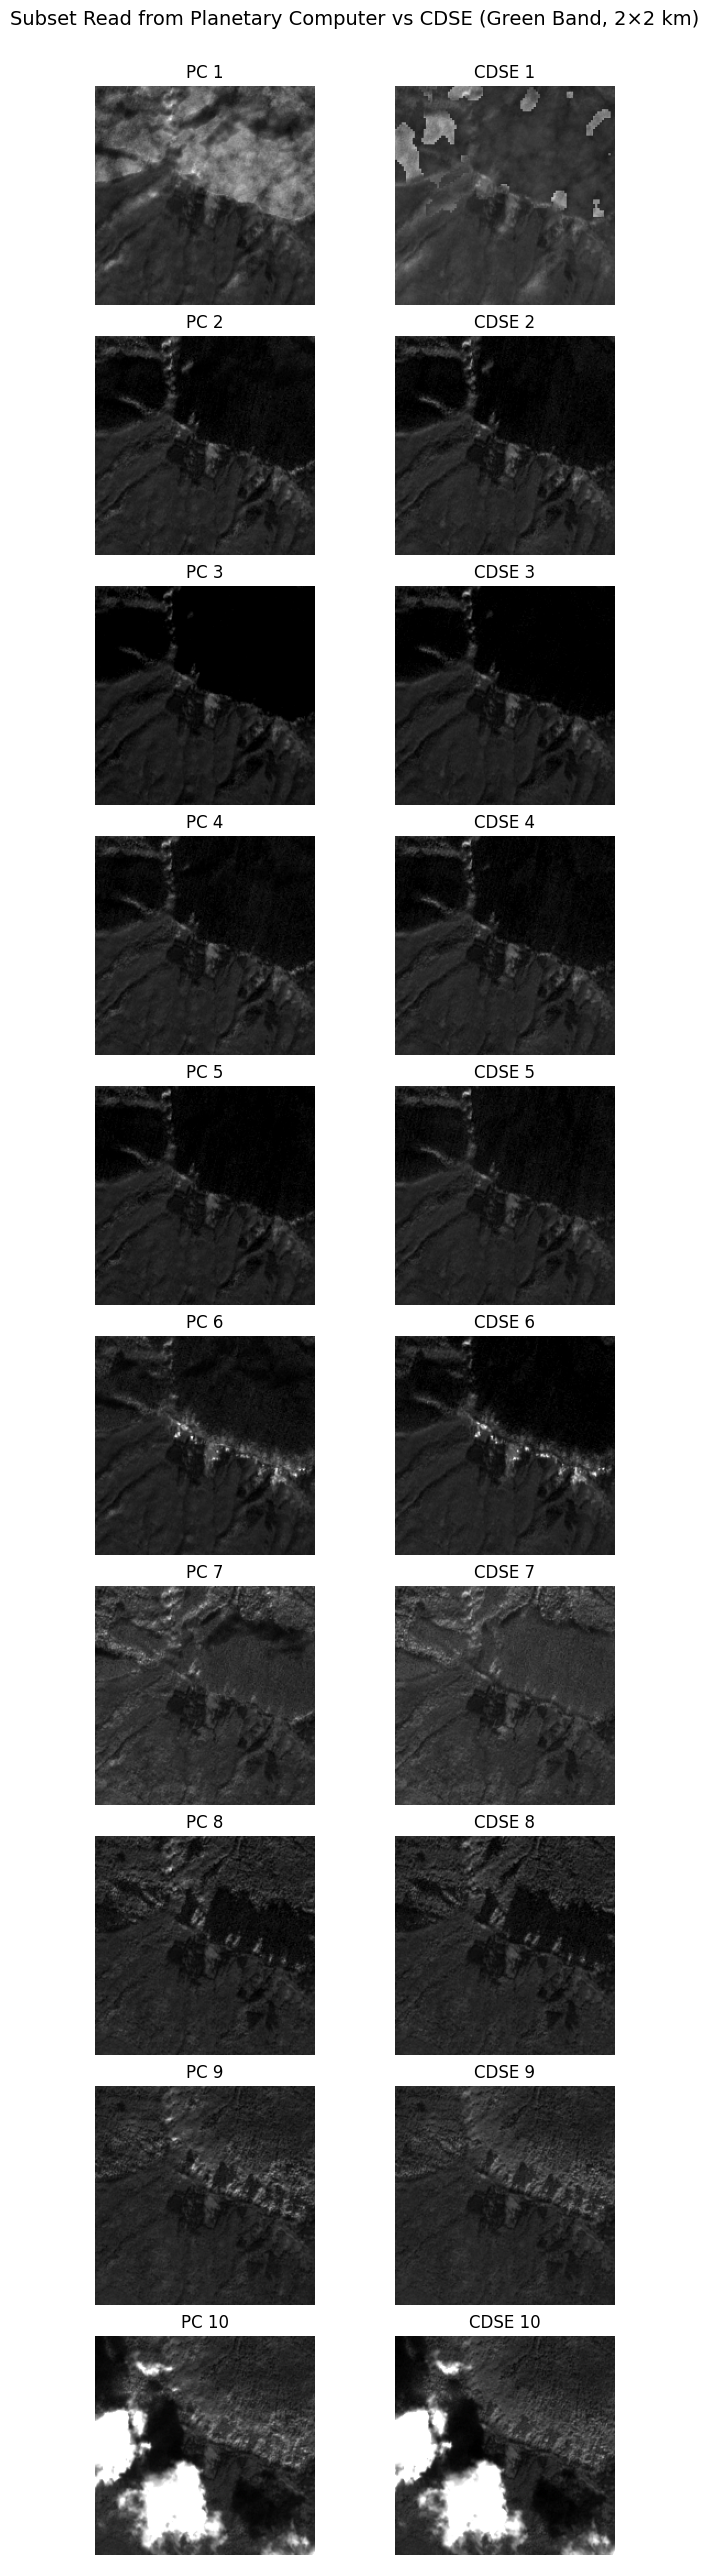

In [73]:
fig, axes = plt.subplots(10, 2, figsize=(6, 25), constrained_layout=True)
axes = axes.flatten()

for i in range(10):
    # Left column: Planetary Computer
    axes[2*i].imshow(pc_greens[i], cmap='gray', vmin=0, vmax=2000)
    axes[2*i].set_title(f'PC {i+1}')
    axes[2*i].axis('off')

    # Right column: CDSE
    axes[2*i+1].imshow(cdse_greens[i].astype(np.int16) - 1000, cmap='gray', vmin=0, vmax=2000)
    axes[2*i+1].set_title(f'CDSE {i+1}')
    axes[2*i+1].axis('off')

plt.suptitle("Subset Read from Planetary Computer vs CDSE (Green Band, 2×2 km)", fontsize=14, y=1.02)
plt.show()

# Results So Far

| Platform             | Format        | Time to read 10 assets |
|----------------------|---------------|-------------------------|
| Planetary Computer   | COG (TIFF)    | ~2 seconds              |
| CDSE (Sentinel-2)    | JPEG 2000     | ~87 seconds             |

We observe a **large performance gap**: reading a small spatial subset (2 × 2 km) from Sentinel-2 images is **much faster on the Planetary Computer** than on CDSE.

This raises the question:  
Is the slowdown on CDSE primarily due to the **JPEG 2000 format**, or is it caused by **other infrastructure-level factors** (e.g., S3 performance, bandwidth, etc.)?

### Next: Test CDSE Cloud-Optimized GeoTIFFs

To isolate the role of the **file format**, we repeat the benchmark using **CDSE-hosted Sentinel-1 mosaics**, which are served as **Cloud-Optimized GeoTIFFs (COGs)** — the same format used on the Planetary Computer.

By comparing read performance between CDSE JP2 files and CDSE COGs, we can better understand whether the bottleneck lies in the data format or the backend infrastructure.


In [67]:
cdse_cog_assets = [
    's3://eodata/Global-Mosaics/Sentinel-1/S1SAR_L3_IW_MCM/2023/01/01/Sentinel-1_IW_mosaic_2023_M01_32TMR_0_0/VH.tif',
    's3://eodata/Global-Mosaics/Sentinel-1/S1SAR_L3_IW_MCM/2022/12/01/Sentinel-1_IW_mosaic_2022_M12_32TMR_0_0/VH.tif',
    's3://eodata/Global-Mosaics/Sentinel-1/S1SAR_L3_IW_MCM/2022/11/01/Sentinel-1_IW_mosaic_2022_M11_32TMR_0_0/VH.tif',
    's3://eodata/Global-Mosaics/Sentinel-1/S1SAR_L3_IW_MCM/2022/09/01/Sentinel-1_IW_mosaic_2022_M09_32TMR_0_0/VH.tif',
    's3://eodata/Global-Mosaics/Sentinel-1/S1SAR_L3_IW_MCM/2022/07/01/Sentinel-1_IW_mosaic_2022_M07_32TMR_0_0/VH.tif',
    's3://eodata/Global-Mosaics/Sentinel-1/S1SAR_L3_IW_MCM/2022/05/01/Sentinel-1_IW_mosaic_2022_M05_32TMR_0_0/VH.tif',
    's3://eodata/Global-Mosaics/Sentinel-1/S1SAR_L3_IW_MCM/2022/04/01/Sentinel-1_IW_mosaic_2022_M04_32TMR_0_0/VH.tif',
    's3://eodata/Global-Mosaics/Sentinel-1/S1SAR_L3_IW_MCM/2022/03/01/Sentinel-1_IW_mosaic_2022_M03_32TMR_0_0/VH.tif',
    's3://eodata/Global-Mosaics/Sentinel-1/S1SAR_L3_IW_MCM/2022/02/01/Sentinel-1_IW_mosaic_2022_M02_32TMR_0_0/VH.tif',
    's3://eodata/Global-Mosaics/Sentinel-1/S1SAR_L3_IW_MCM/2022/01/01/Sentinel-1_IW_mosaic_2022_M01_32TMR_0_0/VH.tif'
]

In [68]:
# Due to the difference in resolution (10m vs 20m), we extend the bounding box and window to read the same amount of data
# Data volume transferred should be about double though due to float32 data type
bbox_extended = box(*bbox_utm).buffer(1000).bounds
# Get spatial window (based on first PC item)
with rasterio.Env(session=session, AWS_VIRTUAL_HOSTING=False):
    with rasterio.open(cdse_cog_assets[0]) as src:
        transform = src.transform
        window = windows.from_bounds(*bbox_extended, transform=transform)

In [70]:
cdse_vhs = []
with timer('CDSE COG 10 assets'):
    with rasterio.Env(session=session, AWS_VIRTUAL_HOSTING=False):
        for asset in cdse_cog_assets:
            with rasterio.open(asset) as con:
                cdse_vhs.append(con.read(1, window=window))

CDSE COG 10 assets -- Time: 11.230


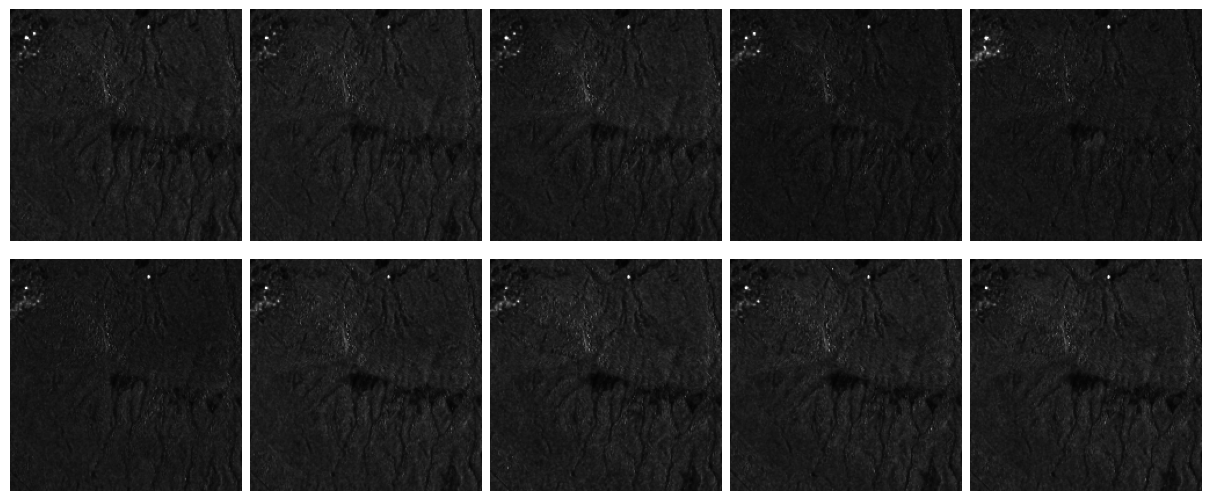

In [71]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5), constrained_layout=True)
axes = axes.flatten()

for ax, img in zip(axes, cdse_vhs):
    ax.imshow(img, cmap='gray', vmin=0, vmax=0.5)
    ax.axis('off')

# Final Results and Conclusion

| Source               | Format        | Platform       | Time to read 10 assets |
|----------------------|---------------|----------------|-------------------------|
| Sentinel-2 (Green)   | COG (TIFF)    | Planetary      | ~2 seconds              |
| Sentinel-2 (Green)   | JPEG 2000     | CDSE           | ~87 seconds             |
| Sentinel-1 (VH)      | COG (TIFF)    | CDSE           | ~11 seconds             |

### ✅ Conclusion

This benchmark demonstrates that **data format plays a critical role in remote I/O performance**:

- **Cloud-Optimized GeoTIFFs (COGs)** offer fast and efficient access to spatial subsets, both on the Planetary Computer and on CDSE.
- **JPEG 2000 files on CDSE** are dramatically slower to read — over **40× slower** in this test — even though the spatial subset and pixel count are identical to the COG cases.

The poor performance of `.jp2` files is likely largely due to the **absence of the Tile-part Length Marker (TLM)** in their encoding. Without TLMs, JPEG 2000 decoders cannot efficiently seek to specific tiles and must read the file sequentially, resulting in many redundant requests and significantly increased latency.

This technical limitation is well documented in the [sentinel-2-jp2-tlm benchmark](https://github.com/Kayrros/sentinel-2-jp2-tlm), which shows that simply enabling TLM during encoding brings `.jp2` access speed in line with COGs.

In short: **the performance bottleneck is format-related, not infrastructure-related**.
